In [1]:
import smart_grid_lab.application.offgrid_h2_forecast as experiment
from smart_grid_lab.application.plot_utils import TelemertyPlotter

In [2]:
time = experiment._default_time()

In [3]:
solar_kW = experiment.sample_solar_kW(time)

In [4]:
load_kW = experiment.sample_load_kW(time)

<Axes: xlabel='utc_timestamp'>

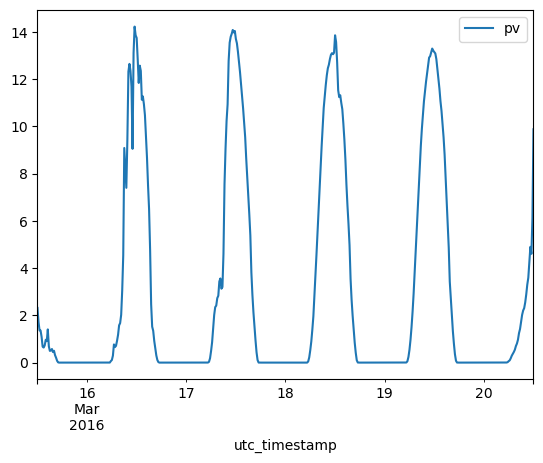

In [6]:
solar_kW.plot()

<Axes: xlabel='utc_timestamp'>

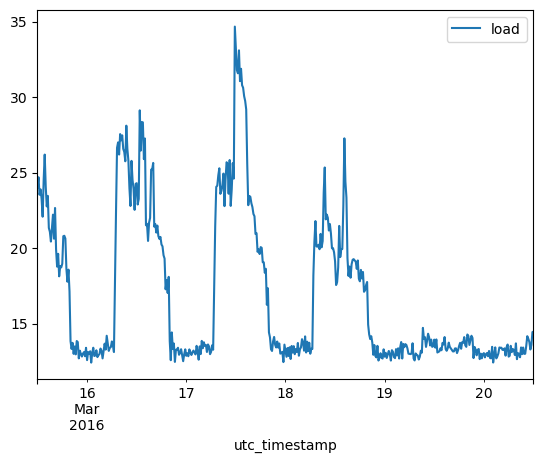

In [7]:
load_kW.plot()

In [10]:
battery_config = experiment.BatteryConfig(100.0, 30.0, 30.0, 0.95, 0.95, 0.5)
battery = experiment._build_battery(battery_config)

In [11]:
h2_config = experiment.H2Config()

In [ ]:
pv_forecaster = ...

In [ ]:
load_forecaster = ...

In [ ]:
surplus_forecaster = ...

In [ ]:
strategy = experiment._default_strategy()

In [ ]:
result = run_simulation(
    time, solar_kw, load_kw, battery, h2_config, strategy, use_bar=True
)

In [14]:
result.trajectory.head()

,solar_power,load_power,battery_available_power,battery_charge_power,battery_discharge_power,battery_soc
timestamp,,,,,,
2026-03-15 12:00:00,92.316127,21.490142,0.000000,0.000000,0.0,0.500000
2026-03-15 12:10:00,90.399245,22.173398,70.825984,29.797862,0.0,0.547148
2026-03-15 12:20:00,80.904206,26.943066,68.225848,29.676100,0.0,0.594085
2026-03-15 12:30:00,80.884718,31.640157,53.961140,29.482092,0.0,0.640684
2026-03-15 12:40:00,81.212148,27.957794,49.244560,29.174662,0.0,0.686750


In [ ]:
result.metrics.head()

In [ ]:
plotter = TelemertyPlotter(result.trajectory)

In [ ]:
plotter.show()

In [15]:
df = result.trajectory

In [16]:
# import plotly.express as px

import plotly.io as pio
pio.renderers.default = "browser"

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [17]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

left_cols = ["solar_power", "load_power", "battery_available_power", "battery_charge_power", "battery_discharge_power"]
right_cols = ["battery_soc"]

for col in left_cols:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col), secondary_y=False)

for col in right_cols:
    fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col), secondary_y=True)

# Labels
fig.update_layout(title="Microgrid Dynamics")

fig.update_yaxes(title_text="Power (kW)", secondary_y=False)
fig.update_yaxes(title_text="SOC (%)", secondary_y=True)

fig.show()

In [25]:
fig = px.line(
    df.reset_index(),
    x=df.index.name,
    y=df.columns
)
fig.show()